# 🚨 Notebook 03 — Predictor de Riesgo Académico
## Comparación: Random Forest vs GBT vs Regresión Logística

**Objetivo:** Predecir qué instituciones entrarán en riesgo académico el próximo año, comparar modelos y explicar los resultados.

**Prerrequisito:** Ejecutar `python src/ml/risk_predictor.py` primero.

**Definición de Riesgo Académico:**
> Una institución está en riesgo si simultáneamente: *tasa_graduación < percentil 25* AND *tasa_crecimiento_matrícula > percentil 75*
> Es decir: crece rápido pero gradúa poco → señal de insostenibilidad.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

ML_DIR = 'C:\\Users\\sebas\\OneDrive\\Desktop\\Proyecto_Final_BigDataV\\data\\processed\\ml\\'

plt.rcParams.update({
    'figure.facecolor': '#F8F9FA',
    'axes.facecolor':   '#F8F9FA',
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'font.family':      'DejaVu Sans',
    'axes.titlesize':   13,
})

MODEL_COLORS = {
    'RandomForest':      '#1A6B8A',
    'GBT':               '#E8501A',
    'LogisticRegression':'#2E9B8F',
}
print('✅ Setup completo')

✅ Setup completo


In [2]:
# ── Cargar resultados ─────────────────────────────────────────────
comparison  = pd.read_csv(ML_DIR + 'model_comparison.csv')
predictions = pd.read_csv(ML_DIR + 'risk_predictions.csv')
roc_data    = pd.read_csv(ML_DIR + 'roc_data.csv')
feat_imp    = pd.read_csv(ML_DIR + 'feature_importance.csv')

best_model_name = comparison.iloc[0]['modelo']
print(f'🏆 Mejor modelo: {best_model_name}')
print('\n' + comparison[['modelo','AUC_ROC','Accuracy','F1_Score']].to_string(index=False))

🏆 Mejor modelo: RandomForest

            modelo  AUC_ROC  Accuracy  F1_Score
      RandomForest 0.998785  0.990385  0.990388
               GBT 0.997440  0.986264  0.986257
LogisticRegression 0.630360  0.578297  0.557172


---
## 📊 Visualización 1 — Comparación de Métricas: Los 3 Modelos

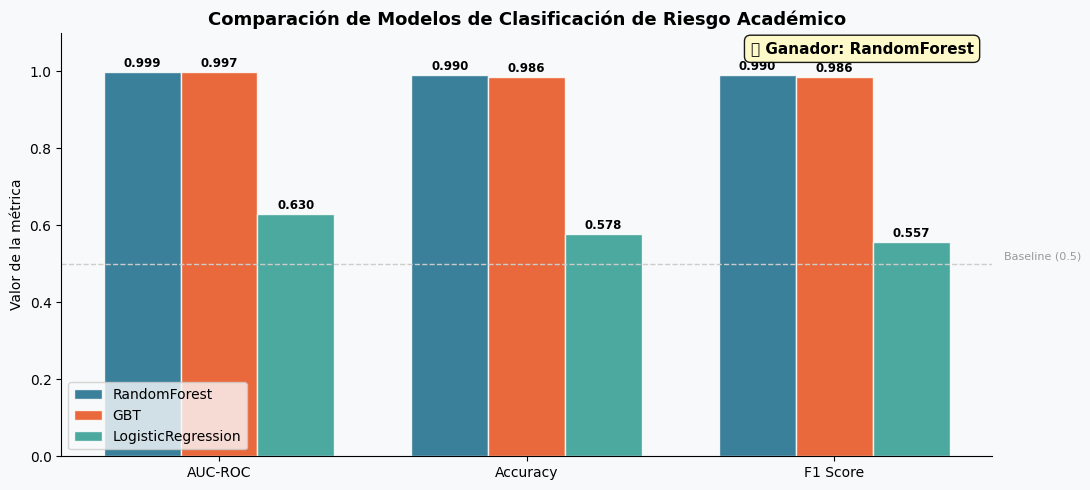

✅ Comparación guardada


In [3]:
metricas = ['AUC_ROC', 'Accuracy', 'F1_Score']
metric_labels = ['AUC-ROC', 'Accuracy', 'F1 Score']

fig, ax = plt.subplots(figsize=(11, 5))

x = np.arange(len(metricas))
width = 0.25

for i, (_, row) in enumerate(comparison.iterrows()):
    color = MODEL_COLORS.get(row['modelo'], '#888')
    vals  = [row[m] for m in metricas]
    bars  = ax.bar(x + i * width, vals, width,
                   label=row['modelo'], color=color, alpha=0.85,
                   edgecolor='white')
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8.5,
                fontweight='bold')

# Destacar el mejor
best_idx = comparison[comparison['mejor'] == True].index
if len(best_idx) > 0:
    ax.text(0.98, 0.98, f'🏆 Ganador: {best_model_name}',
            transform=ax.transAxes, ha='right', va='top',
            fontsize=11, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='#FFF9C4', alpha=0.9))

ax.set_title('Comparación de Modelos de Clasificación de Riesgo Académico',
             fontweight='bold')
ax.set_xticks(x + width)
ax.set_xticklabels(metric_labels)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Valor de la métrica')
ax.legend()
ax.axhline(y=0.5, color='#ccc', linestyle='--', linewidth=1)
ax.text(2.8, 0.51, 'Baseline (0.5)', fontsize=8, color='#999')

plt.tight_layout()
plt.savefig(ML_DIR + '../aggregations/viz_ml1_comparacion_modelos.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('✅ Comparación guardada')

---
## 📉 Visualización 2 — Curvas ROC (los 3 modelos)

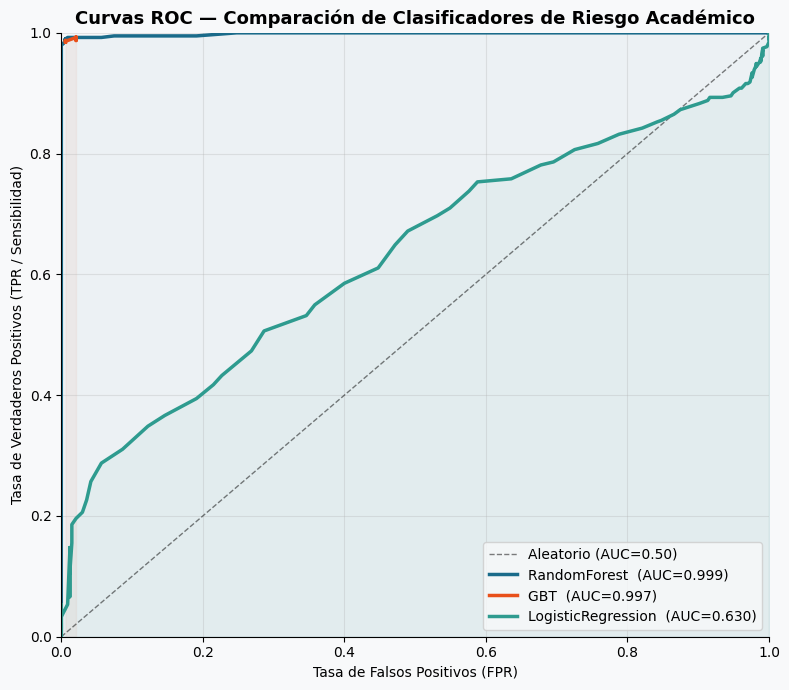

✅ Curvas ROC guardadas


In [4]:
fig, ax = plt.subplots(figsize=(8, 7))

# Diagonal de referencia (clasificador aleatorio)
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5, label='Aleatorio (AUC=0.50)')

for model_name in roc_data['modelo'].unique():
    model_roc = roc_data[roc_data['modelo'] == model_name].sort_values('FPR')
    color = MODEL_COLORS.get(model_name, '#888')

    # AUC del modelo
    auc_val = comparison[comparison['modelo'] == model_name]['AUC_ROC'].values
    auc_str = f'{auc_val[0]:.3f}' if len(auc_val) > 0 else '?'

    ax.plot(model_roc['FPR'], model_roc['TPR'],
            linewidth=2.5, color=color,
            label=f'{model_name}  (AUC={auc_str})')
    ax.fill_between(model_roc['FPR'], model_roc['TPR'], alpha=0.05, color=color)

ax.set_title('Curvas ROC — Comparación de Clasificadores de Riesgo Académico',
             fontweight='bold')
ax.set_xlabel('Tasa de Falsos Positivos (FPR)')
ax.set_ylabel('Tasa de Verdaderos Positivos (TPR / Sensibilidad)')
ax.legend(loc='lower right', fontsize=10)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(ML_DIR + '../aggregations/viz_ml2_curvas_roc.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('✅ Curvas ROC guardadas')

---
## 🎯 Visualización 3 — Feature Importance (RF y GBT)

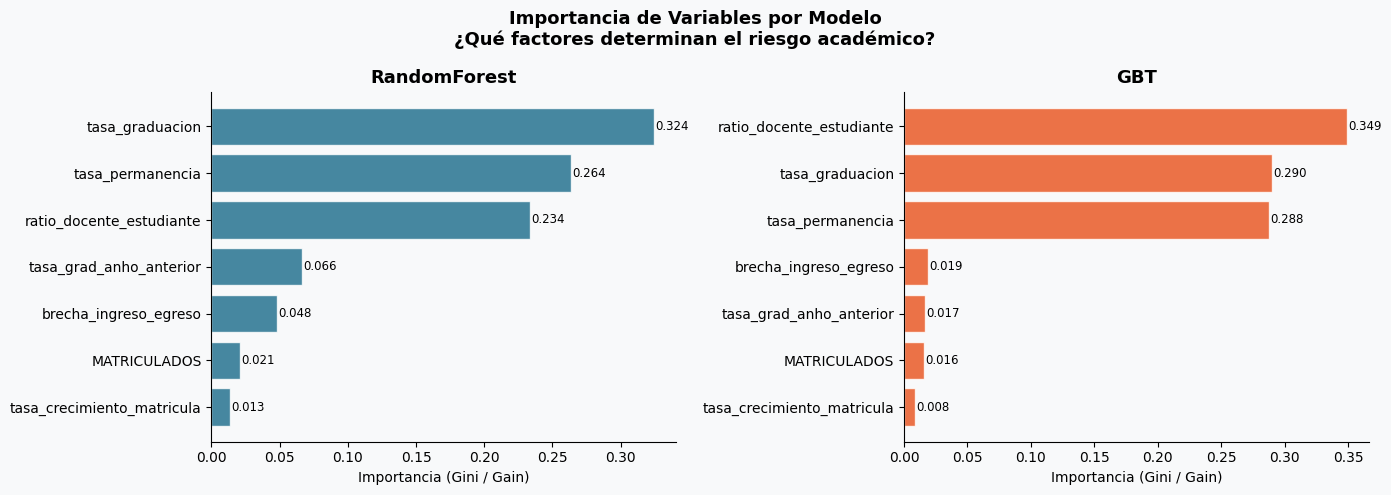

✅ Feature importance guardado


In [5]:
modelos_imp = feat_imp['modelo'].unique()
n_modelos = len(modelos_imp)

fig, axes = plt.subplots(1, n_modelos, figsize=(7 * n_modelos, 5))
if n_modelos == 1:
    axes = [axes]

fig.suptitle('Importancia de Variables por Modelo\n'
             '¿Qué factores determinan el riesgo académico?',
             fontweight='bold', fontsize=13)

for ax, model_name in zip(axes, modelos_imp):
    df_imp = feat_imp[feat_imp['modelo'] == model_name].sort_values('importance', ascending=True)
    color = MODEL_COLORS.get(model_name, '#1A6B8A')

    bars = ax.barh(df_imp['feature'], df_imp['importance'],
                   color=color, alpha=0.8, edgecolor='white')

    for bar, val in zip(bars, df_imp['importance']):
        ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=8.5)

    ax.set_title(f'{model_name}', fontweight='bold')
    ax.set_xlabel('Importancia (Gini / Gain)')

plt.tight_layout()
plt.savefig(ML_DIR + '../aggregations/viz_ml3_feature_importance.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('✅ Feature importance guardado')

---
## 🔴 Visualización 4 — Instituciones en Riesgo (predicciones del mejor modelo)

Período de evaluación: 2022 - 2024
Total instituciones evaluadas:    319
Predichas como riesgo (=1):       390
Real riesgo (label=1):            393


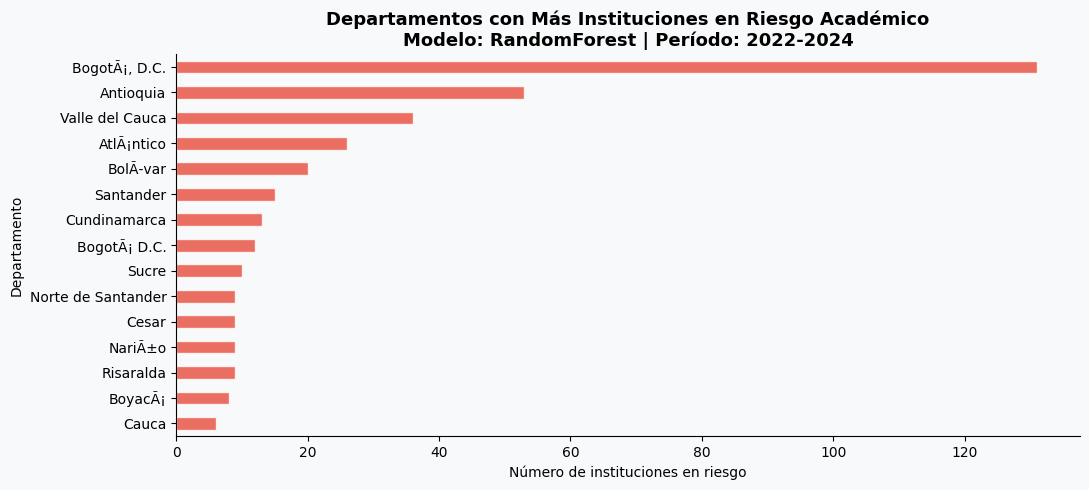

✅ Mapa de riesgo por departamento guardado


In [6]:
# Instituciones predichas como riesgo (prediction=1)
en_riesgo = predictions[predictions['prediction'] == 1].copy()
real_riesgo = predictions[predictions['riesgo_academico'] == 1].copy()

print(f'Período de evaluación: {predictions["AÑO"].min()} - {predictions["AÑO"].max()}')
print(f'Total instituciones evaluadas:    {len(predictions["COD_IES"].unique()):,}')
print(f'Predichas como riesgo (=1):       {len(en_riesgo):,}')
print(f'Real riesgo (label=1):            {len(real_riesgo):,}')

# Top instituciones en riesgo por año
if 'DEPTO_IES' in en_riesgo.columns:
    riesgo_por_depto = en_riesgo.groupby('DEPTO_IES').size().sort_values(ascending=False).head(15)

    fig, ax = plt.subplots(figsize=(11, 5))
    riesgo_por_depto.sort_values().plot(
        kind='barh', ax=ax, color='#E74C3C', alpha=0.8, edgecolor='white'
    )

    ax.set_title(f'Departamentos con Más Instituciones en Riesgo Académico\n'
                 f'Modelo: {best_model_name} | Período: {predictions["AÑO"].min()}-{predictions["AÑO"].max()}',
                 fontweight='bold')
    ax.set_xlabel('Número de instituciones en riesgo')
    ax.set_ylabel('Departamento')

    plt.tight_layout()
    plt.savefig(ML_DIR + '../aggregations/viz_ml4_riesgo_departamentos.png',
                dpi=150, bbox_inches='tight')
    plt.show()

print('✅ Mapa de riesgo por departamento guardado')

---
## 📋 Tabla Final — Ranking de Instituciones de Mayor Riesgo

In [ ]:
if 'NOMBRE_IES' in en_riesgo.columns:
    ranking = (en_riesgo
               .groupby(['COD_IES', 'NOMBRE_IES', 'SECTOR_IES', 'DEPTO_IES'])
               .size()
               .reset_index(name='años_en_riesgo')
               .sort_values('años_en_riesgo', ascending=False)
               .head(20))
    print('🔴 Top 20 instituciones con más años en riesgo académico:')
    print(ranking.to_string(index=False))
    ranking.to_csv(ML_DIR + '../aggregations/ranking_instituciones_riesgo.csv',
                   index=False, encoding='utf-8')
    print('\n✅ Ranking guardado en aggregations/')

🔴 Top 20 instituciones con más años en riesgo académico:
 COD_IES                                                   NOMBRE_IES SECTOR_IES          DEPTO_IES  años_en_riesgo
    1201                                     UNIVERSIDAD DE ANTIOQUIA    Oficial          Antioquia               3
    1120                                UNIVERSIDAD POPULAR DEL CESAR    Oficial              Cesar               3
    1107      UNIVERSIDAD PEDAGOGICA Y TECNOLOGICA DE COLOMBIA - UPTC    Oficial            BoyacÃ¡               3
    1108      UNIVERSIDAD PEDAGOGICA Y TECNOLOGICA DE COLOMBIA - UPTC    Oficial            BoyacÃ¡               3
    1202                                    UNIVERSIDAD DEL ATLANTICO    Oficial         AtlÃ¡ntico               3
    1123                                UNIVERSIDAD POPULAR DEL CESAR    Oficial              Cesar               3
    1119                                    UNIVERSIDAD DE LOS LLANOS    Oficial               Meta               3
    1219       